# 04 Statistical Analysis and KPIs

In this notebook, I'll calculate some specific numbers like Year-over-Year (YoY) growth and identify which districts are not doing well compared to the rest of India.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load the cleaned data
df = pd.read_csv("../data/processed/APY_cleaned.csv")
df.head()

,state,district,crop,crop_year,season,area,production,yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.399820
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.400025
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.737883
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.641428
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.751264


## 1. Comparing crops to national average

I'll first find the median yield for every crop across all of India.

In [6]:
crop_medians = df.groupby('crop')['yield'].median()
print("National Median Yield for some crops:")
crop_medians.head(10)

National Median Yield for some crops:


crop
Arecanut          1.234661
Arhar/Tur         0.792839
Bajra             1.142857
Banana           22.914564
Barley            1.801928
Black pepper      0.645833
Cardamom          0.092547
Cashewnut         0.408203
Castor seed       0.545057
Coconut         317.418182
Name: yield, dtype: float64

## 2. Year-over-Year Production Growth

I want to see how much production changes each year. This helps us see if the agricultural policy is working.

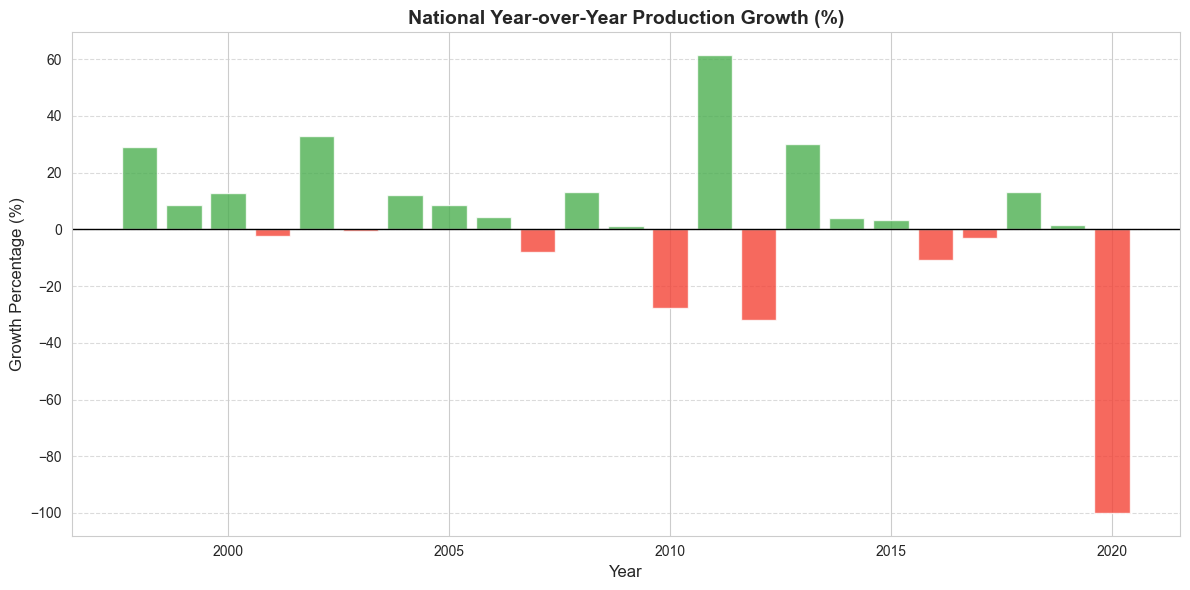

In [7]:
annual_prod = df.groupby('crop_year')['production'].sum()
growth = annual_prod.pct_change() * 100

# Setting colors based on positive or negative growth
colors = ['#4caf50' if x > 0 else '#f44336' for x in growth.values]

plt.figure(figsize=(12, 6))
plt.bar(growth.index, growth.values, color=colors, alpha=0.8)
plt.axhline(0, color='black', linewidth=1, linestyle='-')
plt.title('National Year-over-Year Production Growth (%)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Finding underperforming districts

I'll mark an entry as 'underperforming' if its yield is less than the national median for that specific crop.

In [8]:
# I need to map the medians back to the original data
df['median_for_this_crop'] = df['crop'].map(crop_medians)

# Mark as 1 if it is underperforming, else 0
df['underperforming'] = 0
df.loc[df['yield'] < df['median_for_this_crop'], 'underperforming'] = 1

districts_ranking = df.groupby(['state', 'district'])['underperforming'].mean().sort_values(ascending=False)

print("Districts that underperform most often:")
districts_ranking.head(10)

Districts that underperform most often:


state                       district               
Maharashtra                 MUMBAI SUBURBAN            1.000000
THE DADRA AND NAGAR HAVELI  DAMAN                      1.000000
Daman and Diu               DAMAN                      1.000000
Maharashtra                 MUMBAI                     1.000000
Assam                       SOUTH SALMARA MANCACHAR    1.000000
Laddak                      KARGIL                     0.952381
Jammu and Kashmir           RAMBAN                     0.950820
                            KARGIL                     0.933333
Chhattisgarh                KOREA                      0.930163
Odisha                      KANDHAMAL                  0.893411
Name: underperforming, dtype: float64